In [14]:
# Check latest available date
import datetime
today = datetime.date.today()
print(f"Today: {today}")
print(f"Data available from: 2025-01-01")
print(f"That's approximately {(today - datetime.date(2025, 1, 1)).days} days of data")

Today: 2026-03-19
Data available from: 2025-01-01
That's approximately 442 days of data


In [16]:
from dateutil.relativedelta import relativedelta
import time
import datetime

# Generate monthly chunks
start = datetime.date(2025, 1, 1)
end = datetime.date(2026, 3, 19)

months = []
current = start
while current <= end:
    month_end = min(current + relativedelta(months=1) - datetime.timedelta(days=1), end)
    months.append((current.strftime('%Y-%m-%d'), month_end.strftime('%Y-%m-%d')))
    current += relativedelta(months=1)

print(f"Fetching {len(months)} months...")

# Fetch actuals
all_actuals = []
for m_start, m_end in months:
    print(f"Actuals {m_start[:7]}...", end=' ')
    df = fetch_actuals(m_start, m_end)
    all_actuals.append(df)
    print(f"{len(df)} ✅")
    time.sleep(0.3)

# Fetch forecasts
all_forecasts = []
for m_start, m_end in months:
    print(f"Forecasts {m_start[:7]}...", end=' ')
    df = fetch_forecasts(m_start, m_end)
    all_forecasts.append(df)
    print(f"{len(df)} ✅")
    time.sleep(0.3)

# Combine
actuals_all = pd.concat(all_actuals, ignore_index=True)
actuals_all = actuals_all.drop_duplicates(subset=['startTime']).sort_values('startTime').reset_index(drop=True)

forecasts_all = pd.concat(all_forecasts, ignore_index=True)
forecasts_all = forecasts_all.drop_duplicates().sort_values(['startTime','publishTime']).reset_index(drop=True)

print(f"\n✅ Actuals: {len(actuals_all)} records")
print(f"✅ Forecasts: {len(forecasts_all)} records")
print(f"Date range: {actuals_all['startTime'].min()} to {actuals_all['startTime'].max()}")

Fetching 15 months...
Actuals 2025-01... 1488 ✅
Actuals 2025-02... 1344 ✅
Actuals 2025-03... 1486 ✅
Actuals 2025-04... 1440 ✅
Actuals 2025-05... 1488 ✅
Actuals 2025-06... 1440 ✅
Actuals 2025-07... 1488 ✅
Actuals 2025-08... 1488 ✅
Actuals 2025-09... 1440 ✅
Actuals 2025-10... 1490 ✅
Actuals 2025-11... 1440 ✅
Actuals 2025-12... 1488 ✅
Actuals 2026-01... 1488 ✅
Actuals 2026-02... 1344 ✅
Actuals 2026-03... 871 ✅
Forecasts 2025-01... 11873 ✅
Forecasts 2025-02... 10724 ✅
Forecasts 2025-03... 11867 ✅
Forecasts 2025-04... 11430 ✅
Forecasts 2025-05... 11811 ✅
Forecasts 2025-06... 11430 ✅
Forecasts 2025-07... 11763 ✅
Forecasts 2025-08... 11763 ✅
Forecasts 2025-09... 11430 ✅
Forecasts 2025-10... 11825 ✅
Forecasts 2025-11... 11490 ✅
Forecasts 2025-12... 11873 ✅
Forecasts 2026-01... 11873 ✅
Forecasts 2026-02... 10724 ✅
Forecasts 2026-03... 6942 ✅

✅ Actuals: 21223 records
✅ Forecasts: 168818 records
Date range: 2025-01-01 00:00:00+00:00 to 2026-03-19 03:00:00+00:00


In [17]:
# First apply 4h horizon filter on full dataset
print("Applying 4h horizon filter on full dataset...")
matched_all = apply_horizon_filter(actuals_all, forecasts_all, horizon_hours=4)
matched_all['error'] = matched_all['forecast'] - matched_all['actual']
matched_all['abs_error'] = matched_all['error'].abs()
matched_all['pct_error'] = (matched_all['error'] / matched_all['actual']) * 100
matched_all['hour'] = matched_all['time'].dt.hour
matched_all['dayofweek'] = matched_all['time'].dt.day_name()
matched_all['month'] = matched_all['time'].dt.strftime('%Y-%m')

print(f"Total matched points: {len(matched_all)}")
print(f"Date range: {matched_all['time'].min()} to {matched_all['time'].max()}")

Applying 4h horizon filter on full dataset...
Total matched points: 10605
Date range: 2025-01-01 07:00:00+00:00 to 2026-03-19 03:00:00+00:00


### Analysis 1: Error Distribution Plot
Is the forecast error normally distributed, or does it have a systematic skew that reveals model bias?

In [20]:
# Fix % error — exclude zero actuals
matched_all['pct_error'] = np.where(
    matched_all['actual'] > 0,
    (matched_all['error'] / matched_all['actual']) * 100,
    np.nan
)

mae = matched_all['abs_error'].mean()
bias = matched_all['error'].mean()
median_ae = matched_all['abs_error'].median()
rmse = np.sqrt((matched_all['error'] ** 2).mean())
p99 = matched_all['abs_error'].quantile(0.99)
mean_pct = matched_all['pct_error'].dropna().mean()
std_err = matched_all['error'].std()
mean_actual = matched_all['actual'].mean()
mae_pct = (mae / mean_actual) * 100

interpretations = {
    'Mean Error (Bias)': (
        f"+{bias:,.0f} MW",
        "The average signed difference between forecast and actual. "
        f"A positive bias of +{bias:,.0f} MW means the model systematically overestimates "
        "wind generation at nearly every timestep — indicating a calibration issue "
        "rather than purely random error. Grid operators must account for this consistent "
        "overestimation when making dispatch decisions."
    ),
    'Mean Absolute Error (MAE)': (
        f"{mae:,.0f} MW",
        f"The average magnitude of forecast errors, ignoring direction. "
        f"An MAE of {mae:,.0f} MW means the model is typically off by ~{mae/1000:.1f} GW "
        "on any given half-hour timestep. This is the most intuitive measure of "
        "day-to-day forecasting accuracy for operational use."
    ),
    'Median Absolute Error': (
        f"{median_ae:,.0f} MW",
        f"The middle value of all absolute errors — half of predictions have errors "
        f"below {median_ae:,.0f} MW. Since median ({median_ae:,.0f}) is lower than MAE ({mae:,.0f}), "
        "most predictions are reasonably accurate but a minority of large errors "
        "are pulling the average upward."
    ),
    'RMSE': (
        f"{rmse:,.0f} MW",
        f"Root Mean Squared Error penalizes large errors more heavily than MAE. "
        f"An RMSE of {rmse:,.0f} MW vs MAE of {mae:,.0f} MW confirms the model "
        "occasionally makes very large mistakes. The gap between RMSE and MAE "
        "is a signal of how damaging the outlier errors are."
    ),
    'P99 Absolute Error': (
        f"{p99:,.0f} MW",
        f"The error below which 99% of all predictions fall. A P99 of {p99:,.0f} MW "
        "means 1 in 100 forecasts is off by more than ~{p99/1000:.1f} GW — a serious "
        "risk for grid stability. In energy systems, these rare extreme failures "
        "are as important as average performance."
    ),
    'Mean % Error': (
        f"{mean_pct:.1f}%",
        f"Error expressed as a percentage of actual generation (zero-actual timesteps excluded). "
        f"At {mean_pct:.1f}%, the model appears reasonable in relative terms, but this "
        "masks large absolute errors during low-wind periods where even small MW "
        "deviations represent a high percentage."
    ),
    'Std of Error': (
        f"{std_err:,.0f} MW",
        f"Measures how widely errors are spread around the mean bias. "
        f"A standard deviation of {std_err:,.0f} MW is very high relative to the mean error, "
        "indicating the model is highly inconsistent — sometimes accurate, sometimes "
        "severely wrong. This unpredictability is a major operational challenge."
    ),
    'MAE as % of Mean Actual': (
        f"{mae_pct:.1f}%",
        f"MAE normalized by average actual generation ({mean_actual:,.0f} MW) gives a "
        f"scale-independent accuracy measure. At {mae_pct:.1f}%, the model has moderate "
        "accuracy — workable for general planning but insufficient for high-confidence "
        "real-time operational decisions where sub-5% error is typically required."
    ),
}

# Build DataFrame
metrics_display = pd.DataFrame({
    'Value': [v[0] for v in interpretations.values()],
    'Interpretation': [v[1] for v in interpretations.values()],
}, index=interpretations.keys())

# Color scheme — professional dark blue/teal
def color_rows(row):
    colors = {
        'Mean Error (Bias)':         '#fff8e1',
        'Mean Absolute Error (MAE)': '#e3f2fd',
        'Median Absolute Error':     '#e8f5e9',
        'RMSE':                      '#fce4ec',
        'P99 Absolute Error':        '#fce4ec',
        'Mean % Error':              '#e8f5e9',
        'Std of Error':              '#fce4ec',
        'MAE as % of Mean Actual':   '#e3f2fd',
    }
    c = colors.get(row.name, '#ffffff')
    return [f'background-color: {c}'] * len(row)

styled = metrics_display.style\
    .apply(color_rows, axis=1)\
    .set_caption("📊 Forecast Error Metrics — 4h Horizon | Jan 2025–Mar 2026 | n=10,605 matched points")\
    .set_properties(**{
        'font-size': '12px',
        'border': '1px solid #dee2e6',
        'text-align': 'left',
        'white-space': 'normal',
        'max-width': '800px',
        'color': 'black',
        'font-weight': 'bold'
    })\
    .set_table_styles([{
        'selector': 'th',
        'props': [
            ('background-color', '#1e3a5f'),
            ('color', 'white'),
            ('font-size', '13px'),
            ('padding', '10px')
        ]
    }, {
        'selector': 'td',
        'props': [('padding', '10px'), ('vertical-align', 'top')]
    }, {
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '10px')]
    }])

display(styled)

,Value,Interpretation
Mean Error (Bias),"+1,290 MW","The average signed difference between forecast and actual. A positive bias of +1,290 MW means the model systematically overestimates wind generation at nearly every timestep — indicating a calibration issue rather than purely random error. Grid operators must account for this consistent overestimation when making dispatch decisions."
Mean Absolute Error (MAE),"1,504 MW","The average magnitude of forecast errors, ignoring direction. An MAE of 1,504 MW means the model is typically off by ~1.5 GW on any given half-hour timestep. This is the most intuitive measure of day-to-day forecasting accuracy for operational use."
Median Absolute Error,"1,084 MW","The middle value of all absolute errors — half of predictions have errors below 1,084 MW. Since median (1,084) is lower than MAE (1,504), most predictions are reasonably accurate but a minority of large errors are pulling the average upward."
RMSE,"2,024 MW","Root Mean Squared Error penalizes large errors more heavily than MAE. An RMSE of 2,024 MW vs MAE of 1,504 MW confirms the model occasionally makes very large mistakes. The gap between RMSE and MAE is a signal of how damaging the outlier errors are."
P99 Absolute Error,"5,822 MW","The error below which 99% of all predictions fall. A P99 of 5,822 MW means 1 in 100 forecasts is off by more than ~{p99/1000:.1f} GW — a serious risk for grid stability. In energy systems, these rare extreme failures are as important as average performance."
Mean % Error,18.1%,"Error expressed as a percentage of actual generation (zero-actual timesteps excluded). At 18.1%, the model appears reasonable in relative terms, but this masks large absolute errors during low-wind periods where even small MW deviations represent a high percentage."
Std of Error,"1,560 MW","Measures how widely errors are spread around the mean bias. A standard deviation of 1,560 MW is very high relative to the mean error, indicating the model is highly inconsistent — sometimes accurate, sometimes severely wrong. This unpredictability is a major operational challenge."
MAE as % of Mean Actual,17.9%,"MAE normalized by average actual generation (8,407 MW) gives a scale-independent accuracy measure. At 17.9%, the model has moderate accuracy — workable for general planning but insufficient for high-confidence real-time operational decisions where sub-5% error is typically required."


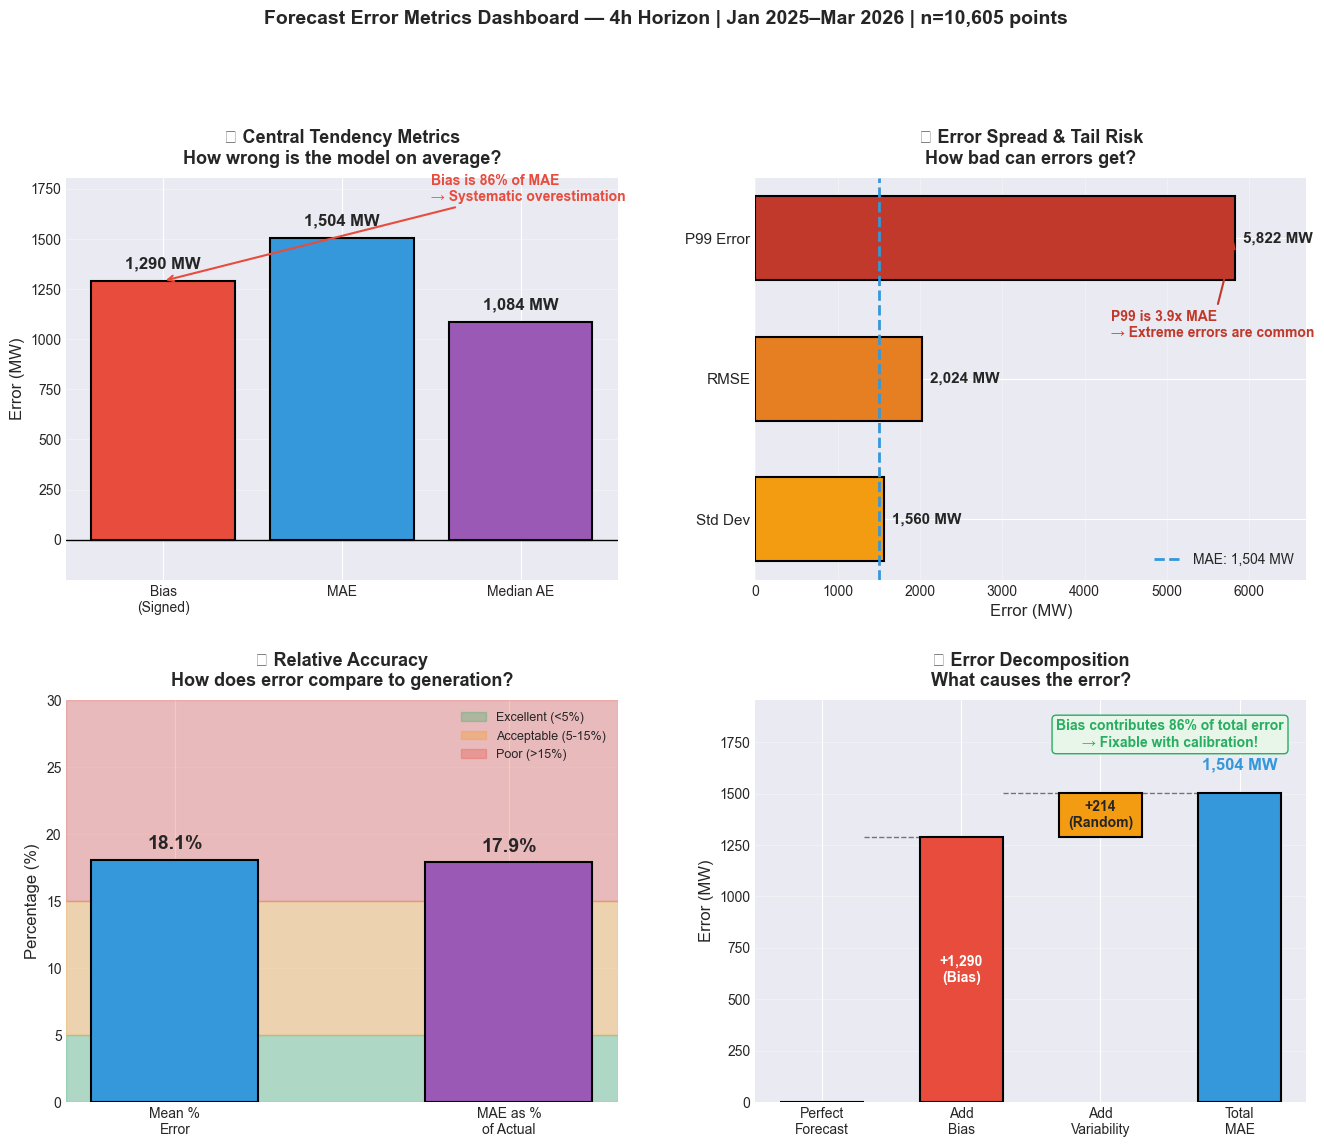

In [58]:
# Visual Error Metrics Dashboard — replacing tabular format
# Fix % error — exclude zero actuals
matched_all['pct_error'] = np.where(
    matched_all['actual'] > 0,
    (matched_all['error'] / matched_all['actual']) * 100,
    np.nan
)

# Compute all metrics
mae = matched_all['abs_error'].mean()
bias = matched_all['error'].mean()
median_ae = matched_all['abs_error'].median()
rmse = np.sqrt((matched_all['error'] ** 2).mean())
p99 = matched_all['abs_error'].quantile(0.99)
mean_pct = matched_all['pct_error'].dropna().mean()
std_err = matched_all['error'].std()
mean_actual = matched_all['actual'].mean()
mae_pct = (mae / mean_actual) * 100

# Create figure with 4 subplots
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

# ============================================================
# Plot 1: Bias & Central Tendency (Top Left)
# Shows: Bias, MAE, Median AE
# ============================================================
ax1 = fig.add_subplot(gs[0, 0])

metrics_central = ['Bias\n(Signed)', 'MAE', 'Median AE']
values_central = [bias, mae, median_ae]
colors_central = ['#e74c3c' if bias > 0 else '#27ae60', '#3498db', '#9b59b6']

bars1 = ax1.bar(metrics_central, values_central, color=colors_central, edgecolor='black', linewidth=1.5)
ax1.axhline(y=0, color='black', linewidth=1)

# Add value labels
for bar, val in zip(bars1, values_central):
    ypos = val + 50 if val >= 0 else val - 150
    ax1.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:,.0f} MW', 
             ha='center', va='bottom' if val >= 0 else 'top', fontsize=12, fontweight='bold')

ax1.set_ylabel('Error (MW)', fontsize=12)
ax1.set_title('① Central Tendency Metrics\nHow wrong is the model on average?', fontsize=13, fontweight='bold', pad=10)
ax1.set_ylim(-200, max(values_central) * 1.2)
ax1.grid(True, alpha=0.3, axis='y')

# Insight annotation
ax1.annotate(f'Bias is {bias/mae*100:.0f}% of MAE\n→ Systematic overestimation', 
             xy=(0, bias), xytext=(1.5, bias + 400),
             fontsize=10, color='#e74c3c', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5))

# ============================================================
# Plot 2: Error Spread & Risk (Top Right)
# Shows: Std Dev, RMSE, P99 as risk gauge
# ============================================================
ax2 = fig.add_subplot(gs[0, 1])

# Create a horizontal bullet-style chart showing error escalation
metrics_risk = ['Std Dev', 'RMSE', 'P99 Error']
values_risk = [std_err, rmse, p99]
colors_risk = ['#f39c12', '#e67e22', '#c0392b']

y_pos = range(len(metrics_risk))
bars2 = ax2.barh(y_pos, values_risk, color=colors_risk, edgecolor='black', linewidth=1.5, height=0.6)

# Add MAE reference line
ax2.axvline(x=mae, color='#3498db', linestyle='--', linewidth=2, label=f'MAE: {mae:,.0f} MW')

# Value labels
for i, (bar, val) in enumerate(zip(bars2, values_risk)):
    ax2.text(val + 100, i, f'{val:,.0f} MW', va='center', fontsize=11, fontweight='bold')

ax2.set_yticks(y_pos)
ax2.set_yticklabels(metrics_risk, fontsize=11)
ax2.set_xlabel('Error (MW)', fontsize=12)
ax2.set_title('② Error Spread & Tail Risk\nHow bad can errors get?', fontsize=13, fontweight='bold', pad=10)
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3, axis='x')
ax2.set_xlim(0, p99 * 1.15)

# Insight annotation
ax2.annotate(f'P99 is {p99/mae:.1f}x MAE\n→ Extreme errors are common', 
             xy=(p99, 2), xytext=(p99 - 1500, 1.3),
             fontsize=10, color='#c0392b', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))

# ============================================================
# Plot 3: Relative Performance (Bottom Left)
# Shows: Mean % Error, MAE % of Actual as gauge
# ============================================================
ax3 = fig.add_subplot(gs[1, 0])

# Create a visual gauge/thermometer for percentage metrics
categories = ['Mean %\nError', 'MAE as %\nof Actual']
values_pct = [mean_pct, mae_pct]

# Target zones
ax3.axhspan(0, 5, alpha=0.3, color='#27ae60', label='Excellent (<5%)')
ax3.axhspan(5, 15, alpha=0.3, color='#f39c12', label='Acceptable (5-15%)')
ax3.axhspan(15, 30, alpha=0.3, color='#e74c3c', label='Poor (>15%)')

bars3 = ax3.bar(categories, values_pct, color=['#3498db', '#9b59b6'], edgecolor='black', linewidth=1.5, width=0.5)

for bar, val in zip(bars3, values_pct):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.8, f'{val:.1f}%', 
             ha='center', fontsize=14, fontweight='bold')

ax3.set_ylabel('Percentage (%)', fontsize=12)
ax3.set_title('③ Relative Accuracy\nHow does error compare to generation?', fontsize=13, fontweight='bold', pad=10)
ax3.set_ylim(0, 30)
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# ============================================================
# Plot 4: Error Decomposition Waterfall (Bottom Right)
# Shows: How total error breaks down
# ============================================================
ax4 = fig.add_subplot(gs[1, 1])

# Waterfall-style breakdown
labels = ['Perfect\nForecast', 'Add\nBias', 'Add\nVariability', 'Total\nMAE']
values_waterfall = [0, bias, mae - bias, mae]
cumulative = [0, bias, mae, mae]

colors_waterfall = ['#27ae60', '#e74c3c', '#f39c12', '#3498db']

# Draw waterfall bars
for i in range(len(labels)):
    if i == 0:
        ax4.bar(i, 0.1, bottom=0, color=colors_waterfall[i], edgecolor='black', linewidth=1.5, width=0.6)
    elif i == len(labels) - 1:
        ax4.bar(i, mae, bottom=0, color=colors_waterfall[i], edgecolor='black', linewidth=1.5, width=0.6)
    else:
        bottom = cumulative[i-1] if values_waterfall[i] > 0 else cumulative[i]
        ax4.bar(i, abs(values_waterfall[i]), bottom=min(cumulative[i-1], cumulative[i]), 
                color=colors_waterfall[i], edgecolor='black', linewidth=1.5, width=0.6)

# Connect bars with lines
for i in range(len(labels) - 1):
    ax4.plot([i + 0.3, i + 0.7], [cumulative[i+1], cumulative[i+1]], 'k--', linewidth=1, alpha=0.5)

# Value labels
ax4.text(1, bias/2, f'+{bias:,.0f}\n(Bias)', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
ax4.text(2, bias + (mae-bias)/2, f'+{mae-bias:,.0f}\n(Random)', ha='center', va='center', fontsize=10, fontweight='bold')
ax4.text(3, mae + 100, f'{mae:,.0f} MW', ha='center', va='bottom', fontsize=12, fontweight='bold', color='#3498db')

ax4.set_xticks(range(len(labels)))
ax4.set_xticklabels(labels, fontsize=10)
ax4.set_ylabel('Error (MW)', fontsize=12)
ax4.set_title('④ Error Decomposition\nWhat causes the error?', fontsize=13, fontweight='bold', pad=10)
ax4.set_ylim(0, mae * 1.3)
ax4.grid(True, alpha=0.3, axis='y')

# Insight
bias_contribution = (bias / mae) * 100
ax4.text(2.5, mae * 1.15, f'Bias contributes {bias_contribution:.0f}% of total error\n→ Fixable with calibration!', 
         fontsize=10, fontweight='bold', color='#27ae60', ha='center',
         bbox=dict(boxstyle='round', facecolor='#e8f5e9', edgecolor='#27ae60'))

plt.suptitle('Forecast Error Metrics Dashboard — 4h Horizon | Jan 2025–Mar 2026 | n=10,605 points', 
             fontsize=14, fontweight='bold', y=1.02)

plt.savefig('error_metrics_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


### Error Analysis with fixes

- **Mean Error (Bias) — +1,290 MW**  
  The model consistently overestimates generation, showing a systematic bias rather than random noise; this can be fixed by applying a simple bias correction (subtracting the mean error) or retraining the model with better calibration.

- **Mean Absolute Error (MAE) — 1,504 MW**  
  On average, predictions are off by ~1.5 GW, indicating moderate day to day accuracy; this can be improved by incorporating more relevant features (e.g., weather variables) or using more expressive models.

- **Median Absolute Error — 1,084 MW**  
  Most predictions are reasonably close, but some large errors inflate the average; reducing outliers (via better handling of extreme conditions) will bring MAE closer to the median.

- **RMSE — 2,024 MW**  
  The higher RMSE compared to MAE shows that large errors occur and are heavily penalized; improving model stability and handling sudden changes (like wind ramps) can reduce these spikes.

- **P99 Absolute Error — 5,822 MW**  
  Rare but severe failures exist where predictions are off by ~5.8 GW, posing reliability risks; this can be addressed by adding uncertainty modeling, fallback rules, or separate models for extreme scenarios.

- **Mean % Error — 18.1%**  
  Relative error appears acceptable but can be misleading during low generation periods; using scale-aware metrics (like MAE alongside %) and improving low-wind predictions can help.

- **Std of Error — 1,560 MW**  
  Errors vary widely, meaning the model is inconsistent across time; this can be improved by making the model more robust to different regimes (e.g., segmenting by conditions or using ensemble methods).

- **MAE as % of Mean Actual — 17.9%**  
  The model’s error is ~18% of typical generation, which is moderate but not reliable for critical decisions; improving feature quality, model tuning, and reducing variance is necessary to reach high-confidence levels.

In [21]:
actuals_2025 = actuals_all[actuals_all['startTime'].dt.year == 2025]
forecasts_2025 = forecasts_all[forecasts_all['publishTime'].dt.year == 2025]

print(f"Actuals 2025: {len(actuals_2025)} records")
print(f"Forecasts 2025: {len(forecasts_2025)} records")
print(f"Months covered: {actuals_2025['startTime'].dt.to_period('M').unique()}")

Actuals 2025: 17520 records
Forecasts 2025: 139279 records
Months covered: <PeriodArray>
['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07',
 '2025-08', '2025-09', '2025-10', '2025-11', '2025-12']
Length: 12, dtype: period[M]


In [22]:
print("Applying 4h horizon filter on 2025 data...")
matched_2025 = apply_horizon_filter(actuals_2025, forecasts_2025, horizon_hours=4)
matched_2025['error'] = matched_2025['forecast'] - matched_2025['actual']
matched_2025['abs_error'] = matched_2025['error'].abs()
matched_2025['pct_error'] = np.where(
    matched_2025['actual'] > 0,
    (matched_2025['error'] / matched_2025['actual']) * 100,
    np.nan
)
matched_2025['month'] = matched_2025['time'].dt.strftime('%Y-%m')
matched_2025['month_name'] = matched_2025['time'].dt.strftime('%b')

print(f"Matched points: {len(matched_2025)}")
print(f"Points per month:\n{matched_2025.groupby('month').size()}")

Applying 4h horizon filter on 2025 data...
Matched points: 8753
Points per month:
month
2025-01    737
2025-02    672
2025-03    744
2025-04    720
2025-05    744
2025-06    720
2025-07    744
2025-08    744
2025-09    720
2025-10    744
2025-11    720
2025-12    744
dtype: int64


In [24]:
def compute_metrics(df):
    mae = df['abs_error'].mean()
    mean_actual = df['actual'].mean()
    return pd.Series({
        'Bias (MW)':            df['error'].mean(),
        'MAE (MW)':             mae,
        'Median AE (MW)':       df['abs_error'].median(),
        'RMSE (MW)':            np.sqrt((df['error'] ** 2).mean()),
        'P99 AE (MW)':          df['abs_error'].quantile(0.99),
        'Mean % Error':         df['pct_error'].dropna().mean(),
        'Std of Error (MW)':    df['error'].std(),
        'MAE % of Actual':      (mae / mean_actual) * 100,
    })

monthly_metrics = matched_2025.groupby('month').apply(compute_metrics)
monthly_metrics.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("Monthly Metrics (2025):")
print(monthly_metrics.round(1).to_string())

Monthly Metrics (2025):
     Bias (MW)  MAE (MW)  Median AE (MW)  RMSE (MW)  P99 AE (MW)  Mean % Error  Std of Error (MW)  MAE % of Actual
Jan      870.7    1073.2           820.0     1424.1       4320.5          18.0             1127.7             13.2
Feb     1577.0    1739.4          1352.0     2234.4       5487.2          16.1             1584.1             18.3
Mar     1528.9    1704.8          1363.0     2117.6       5003.7          25.9             1466.2             24.0
Apr      579.5     743.5           594.5      969.3       2749.7          16.6              777.6             13.8
May      429.6    1022.4           767.0     1474.7       6332.1           6.3             1411.6             16.3
Jun     1550.5    1724.0          1449.5     2165.1       5524.6          24.6             1512.2             23.0
Jul      967.0    1054.9           757.0     1474.5       5278.9          29.3             1113.8             23.6
Aug     1286.5    1466.3           843.5     2160.4     

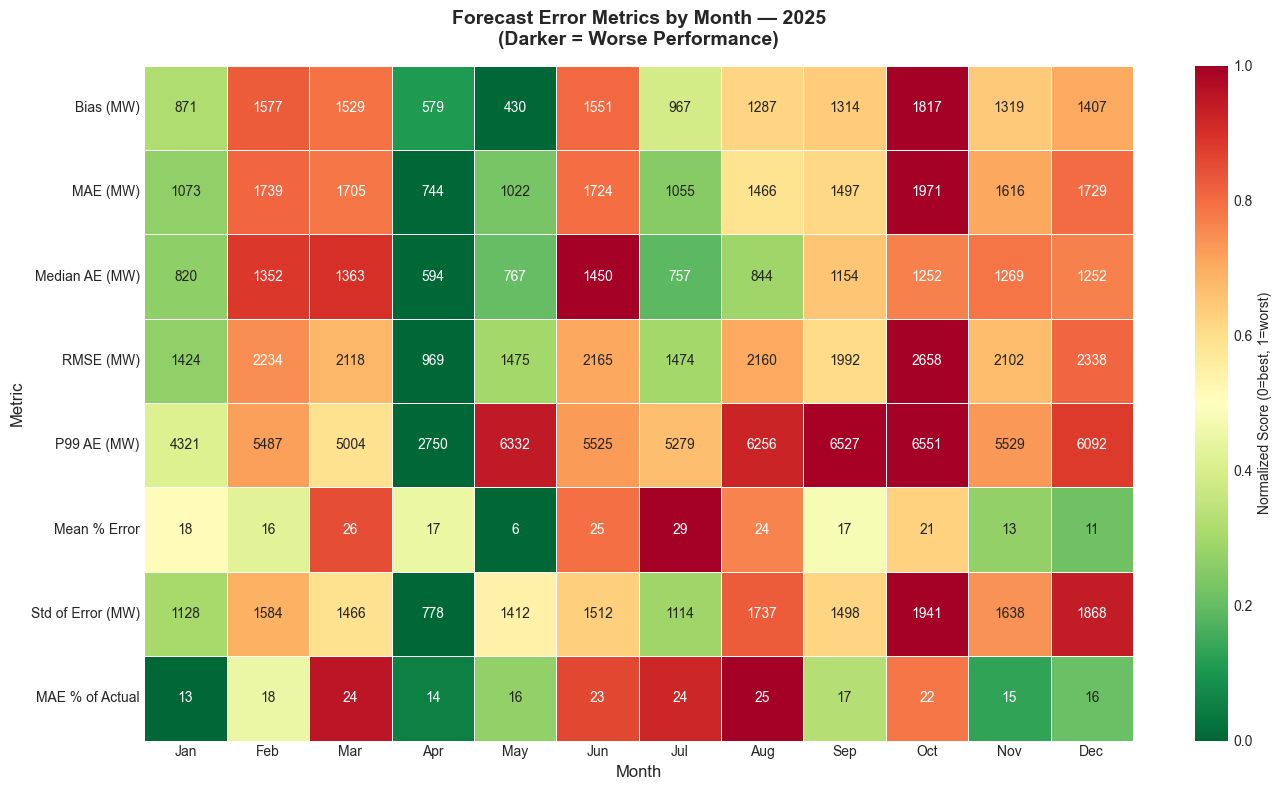

Heatmap saved ✅


In [25]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 8))

# Normalize each column for heatmap coloring
monthly_normalized = monthly_metrics.copy()
for col in monthly_normalized.columns:
    col_min = monthly_normalized[col].min()
    col_max = monthly_normalized[col].max()
    monthly_normalized[col] = (monthly_normalized[col] - col_min) / (col_max - col_min)

sns.heatmap(
    monthly_normalized.T,
    annot=monthly_metrics.round(0).T.astype(int),
    fmt='d',
    cmap='RdYlGn_r',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Normalized Score (0=best, 1=worst)'}
)

ax.set_title('Forecast Error Metrics by Month — 2025\n(Darker = Worse Performance)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Metric', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('heatmap_monthly.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved ✅")

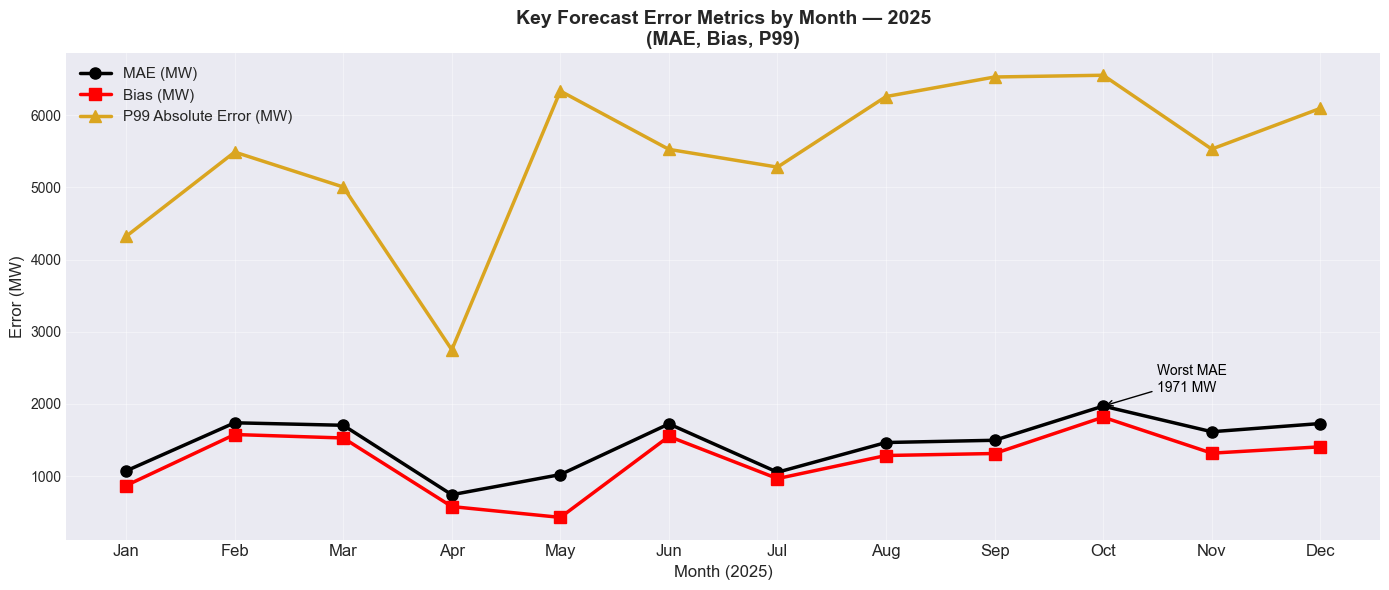

Plot saved ✅


In [26]:
fig, ax = plt.subplots(figsize=(14, 6))

months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x = range(len(months_labels))

ax.plot(x, monthly_metrics['MAE (MW)'], 'o-', color='black', 
        linewidth=2.5, markersize=8, label='MAE (MW)')
ax.plot(x, monthly_metrics['Bias (MW)'], 's-', color='red', 
        linewidth=2.5, markersize=8, label='Bias (MW)')
ax.plot(x, monthly_metrics['P99 AE (MW)'], '^-', color='#DAA520', 
        linewidth=2.5, markersize=8, label='P99 Absolute Error (MW)')

ax.set_xticks(x)
ax.set_xticklabels(months_labels, fontsize=12)
ax.set_ylabel('Error (MW)', fontsize=12)
ax.set_xlabel('Month (2025)', fontsize=12)
ax.set_title('Key Forecast Error Metrics by Month — 2025\n(MAE, Bias, P99)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)

# Annotate highest MAE month
worst_month_idx = monthly_metrics['MAE (MW)'].argmax()
ax.annotate(f"Worst MAE\n{monthly_metrics['MAE (MW)'].max():.0f} MW",
            xy=(worst_month_idx, monthly_metrics['MAE (MW)'].max()),
            xytext=(worst_month_idx + 0.5, monthly_metrics['MAE (MW)'].max() + 200),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, color='black')

plt.tight_layout()
plt.savefig('three_metrics_monthly.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✅")

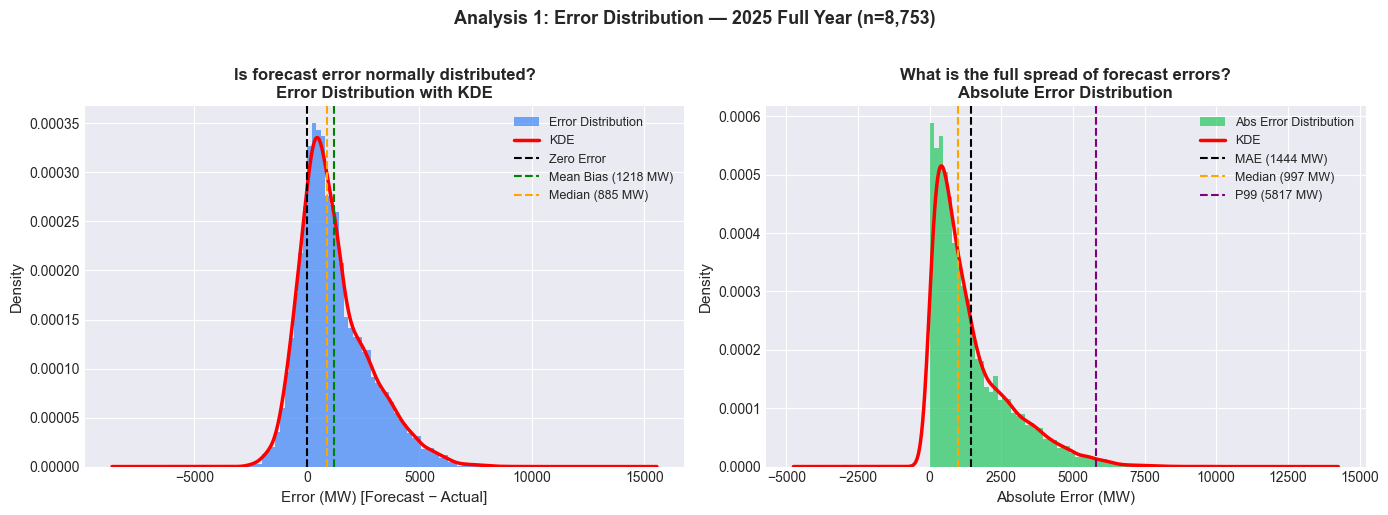

✅ Saved


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Error Distribution ---
axes[0].hist(matched_2025['error'], bins=60, color='#3b82f6', 
             alpha=0.7, density=True, label='Error Distribution')
matched_2025['error'].plot.kde(ax=axes[0], color='red', 
                                linewidth=2.5, label='KDE')
axes[0].axvline(x=0, color='black', linestyle='--', 
                linewidth=1.5, label='Zero Error')
axes[0].axvline(x=matched_2025['error'].mean(), color='green', 
                linestyle='--', linewidth=1.5, 
                label=f"Mean Bias ({matched_2025['error'].mean():.0f} MW)")
axes[0].axvline(x=matched_2025['error'].median(), color='orange', 
                linestyle='--', linewidth=1.5,
                label=f"Median ({matched_2025['error'].median():.0f} MW)")
axes[0].set_xlabel('Error (MW) [Forecast − Actual]', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Is forecast error normally distributed?\nError Distribution with KDE', 
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# --- Plot 2: Absolute Error Distribution ---
axes[1].hist(matched_2025['abs_error'], bins=60, color='#22c55e', 
             alpha=0.7, density=True, label='Abs Error Distribution')
matched_2025['abs_error'].plot.kde(ax=axes[1], color='red', 
                                    linewidth=2.5, label='KDE')
axes[1].axvline(x=matched_2025['abs_error'].mean(), color='black', 
                linestyle='--', linewidth=1.5,
                label=f"MAE ({matched_2025['abs_error'].mean():.0f} MW)")
axes[1].axvline(x=matched_2025['abs_error'].median(), color='orange', 
                linestyle='--', linewidth=1.5,
                label=f"Median ({matched_2025['abs_error'].median():.0f} MW)")
axes[1].axvline(x=matched_2025['abs_error'].quantile(0.99), color='purple', 
                linestyle='--', linewidth=1.5,
                label=f"P99 ({matched_2025['abs_error'].quantile(0.99):.0f} MW)")
axes[1].set_xlabel('Absolute Error (MW)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('What is the full spread of forecast errors?\nAbsolute Error Distribution', 
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Analysis 1: Error Distribution — 2025 Full Year (n=8,753)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('analysis1_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved")

Key findings:

Distribution is right-skewed, not normal — majority of errors are positive (overestimation)
Mean Bias (1,218 MW) > Median (885 MW) — a few extreme overestimates pull the mean up
Long right tail — errors extend to 15,000 MW in rare cases
P99 = 5,817 MW — worst 1% of forecasts are severely wrong
The model almost never severely underestimates (left tail is short)

### Analysis 2: Box Plots by Horizon
How does forecast uncertainty grow as we predict further into the future?

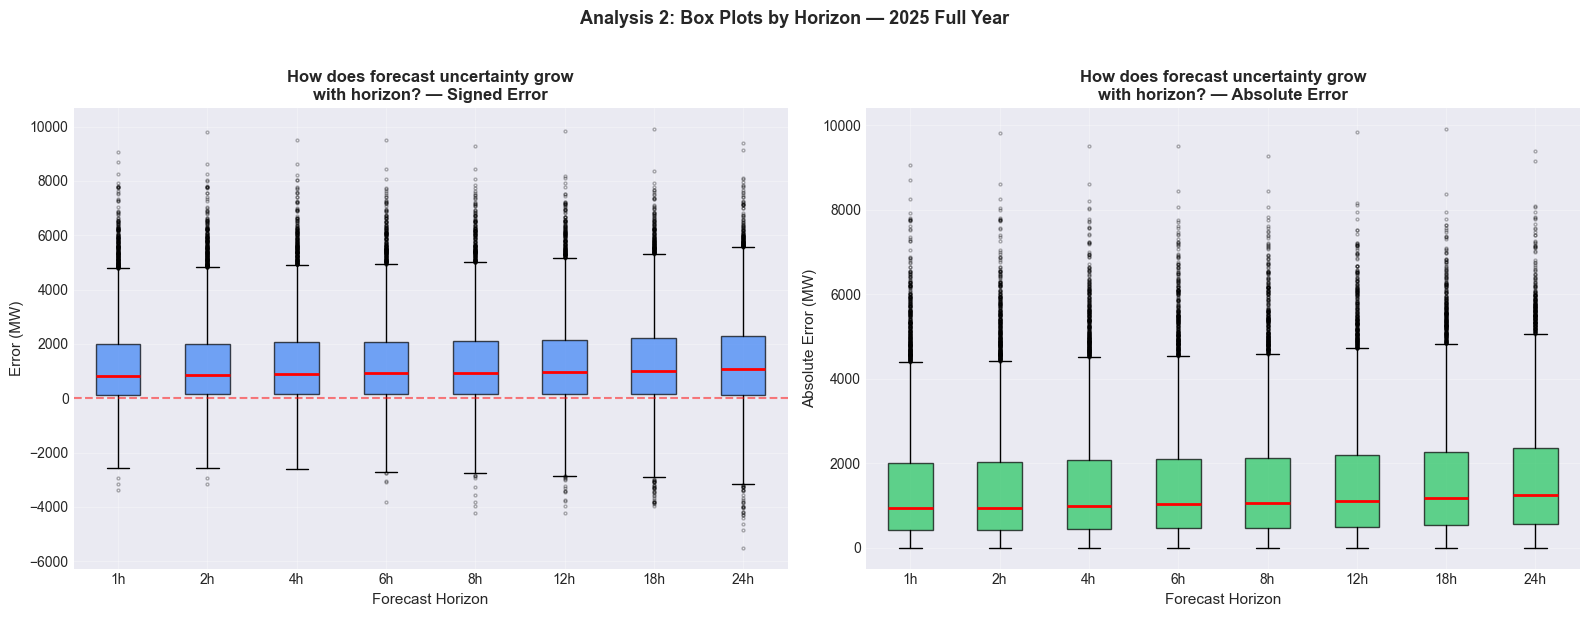

✅ Saved


In [32]:
# Compute for multiple horizons on 2025 data
horizons = [1, 2, 4, 6, 8, 12, 18, 24]
horizon_data_2025 = []

for h in horizons:
    df = apply_horizon_filter(actuals_2025, forecasts_2025, horizon_hours=h)
    df['error'] = df['forecast'] - df['actual']
    df['abs_error'] = df['error'].abs()
    df['horizon'] = h
    horizon_data_2025.append(df)

horizon_combined_2025 = pd.concat(horizon_data_2025, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot — signed error
data_by_horizon = [horizon_combined_2025[horizon_combined_2025['horizon']==h]['error'].values 
                   for h in horizons]
bp1 = axes[0].boxplot(data_by_horizon, labels=[f'{h}h' for h in horizons],
                       patch_artist=True, notch=False,
                       medianprops=dict(color='red', linewidth=2),
                       flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch in bp1['boxes']:
    patch.set_facecolor('#3b82f6')
    patch.set_alpha(0.7)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
axes[0].set_xlabel('Forecast Horizon', fontsize=11)
axes[0].set_ylabel('Error (MW)', fontsize=11)
axes[0].set_title('How does forecast uncertainty grow\nwith horizon? — Signed Error', 
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Box plot — absolute error
data_abs_by_horizon = [horizon_combined_2025[horizon_combined_2025['horizon']==h]['abs_error'].values 
                       for h in horizons]
bp2 = axes[1].boxplot(data_abs_by_horizon, labels=[f'{h}h' for h in horizons],
                       patch_artist=True, notch=False,
                       medianprops=dict(color='red', linewidth=2),
                       flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch in bp2['boxes']:
    patch.set_facecolor('#22c55e')
    patch.set_alpha(0.7)
axes[1].set_xlabel('Forecast Horizon', fontsize=11)
axes[1].set_ylabel('Absolute Error (MW)', fontsize=11)
axes[1].set_title('How does forecast uncertainty grow\nwith horizon? — Absolute Error', 
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Analysis 2: Box Plots by Horizon — 2025 Full Year', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('analysis2_boxplot_horizon.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved")

Key findings:

Median error (red line) stays consistently above zero at all horizons — persistent overestimation regardless of how far ahead we forecast
Box size grows gradually with horizon — IQR widens from 1h to 24h showing increasing uncertainty
Outliers are present at every horizon — extreme errors are not just a long-horizon problem
Lower whisker barely crosses zero — model almost never significantly underestimates
24h horizon shows widest spread — longest horizon has most unpredictable errors

### Analysis 3: Error Percentile Table
What is the full risk profile of forecast errors — from typical to worst-case scenarios?

In [35]:
percentiles = [10, 25, 50, 75, 90, 95, 99]
horizons = [1, 2, 4, 6, 8, 12, 18, 24]

# Build percentile table
rows = []
for h in horizons:
    df = horizon_combined_2025[horizon_combined_2025['horizon'] == h]
    row = {'Horizon': f'{h}h'}
    for p in percentiles:
        row[f'P{p}'] = df['abs_error'].quantile(p/100)
    rows.append(row)

percentile_df = pd.DataFrame(rows).set_index('Horizon')

# Style the table
def color_percentile(val):
    if val < 500:
        return 'background-color: #d4edda; color: black; font-weight: bold'
    elif val < 1000:
        return 'background-color: #fff3cd; color: black; font-weight: bold'
    elif val < 2000:
        return 'background-color: #ffe0b2; color: black; font-weight: bold'
    elif val < 4000:
        return 'background-color: #f8d7da; color: black; font-weight: bold'
    else:
        return 'background-color: #c62828; color: white; font-weight: bold'

styled_table = percentile_df.style\
    .map(color_percentile)\
    .format('{:,.0f} MW')\
    .set_caption(
        'Analysis 3: What is the full risk profile of forecast errors?\n'
        'Absolute Error Percentiles by Horizon — 2025 Full Year'
    )\
    .set_properties(**{
        'font-size': '13px',
        'border': '1px solid #dee2e6',
        'text-align': 'center',
        'padding': '10px',
        'color': 'black',
        'font-weight': 'bold'
    })\
    .set_table_styles([{
        'selector': 'th',
        'props': [
            ('background-color', '#1e3a5f'),
            ('color', 'white'),
            ('font-size', '13px'),
            ('padding', '10px'),
            ('text-align', 'center')
        ]
    }, {
        'selector': 'caption',
        'props': [
            ('font-size', '14px'),
            ('font-weight', 'bold'),
            ('padding', '12px'),
            ('color', 'black')
        ]
    }])

display(styled_table)
print("\nColor guide: 🟢 <500MW  🟡 500-1000MW  🟠 1000-2000MW  🔴 2000-4000MW  ⬛ >4000MW")

,P10,P25,P50,P75,P90,P95,P99
Horizon,,,,,,,
1h,169 MW,413 MW,936 MW,"2,008 MW","3,408 MW","4,267 MW","5,837 MW"
2h,169 MW,420 MW,947 MW,"2,022 MW","3,428 MW","4,271 MW","5,826 MW"
4h,171 MW,439 MW,997 MW,"2,071 MW","3,454 MW","4,271 MW","5,817 MW"
6h,179 MW,457 MW,"1,029 MW","2,090 MW","3,474 MW","4,260 MW","5,855 MW"
8h,187 MW,472 MW,"1,055 MW","2,121 MW","3,491 MW","4,289 MW","5,865 MW"
12h,204 MW,497 MW,"1,109 MW","2,188 MW","3,486 MW","4,314 MW","5,860 MW"
18h,208 MW,543 MW,"1,178 MW","2,260 MW","3,583 MW","4,389 MW","5,820 MW"
24h,217 MW,549 MW,"1,252 MW","2,357 MW","3,693 MW","4,450 MW","5,829 MW"



Color guide: 🟢 <500MW  🟡 500-1000MW  🟠 1000-2000MW  🔴 2000-4000MW  ⬛ >4000MW


Key findings:

P10 stays green across all horizons — 10% of forecasts are very accurate (<220 MW error)
P50 crosses 1,000 MW at 6h horizon — median error exceeds 1 GW for longer horizons
P75 is always red (>2,000 MW) — 25% of forecasts are off by more than 2 GW
P95 and P99 are consistently dark red — extreme errors are a persistent problem regardless of horizon
P99 barely changes across horizons (~5,800 MW) — worst case errors are driven by weather events, not horizon length

### Analysis 4: Error by Month
Which seasons make wind power hardest to forecast?

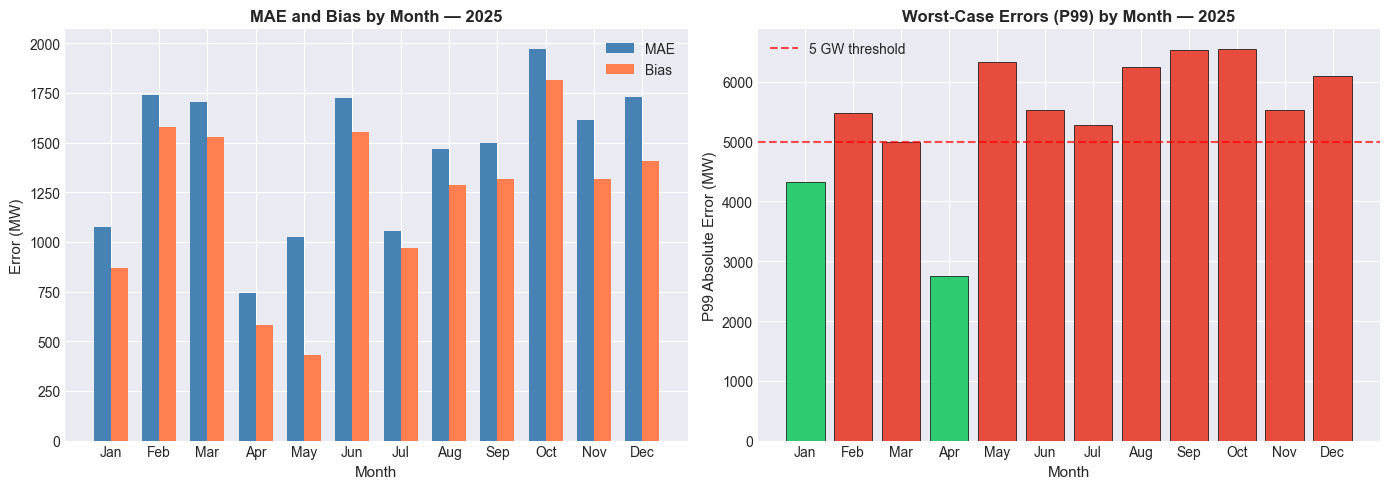


 Seasonal Summary (2025):
--------------------------------------------------
Winter  : MAE=1,514 MW | Bias=+1,285 MW | Max P99=6,092 MW
Spring  : MAE=1,157 MW | Bias=+846 MW | Max P99=6,332 MW
Summer  : MAE=1,415 MW | Bias=+1,268 MW | Max P99=6,256 MW
Autumn  : MAE=1,695 MW | Bias=+1,483 MW | Max P99=6,551 MW

 Best month:  Apr (MAE = 744 MW)
  Worst month: Oct (MAE = 1,971 MW)


In [44]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Use the already-computed monthly_metrics DataFrame
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: MAE and Bias by month
ax1 = axes[0]
x = range(len(month_order))
width = 0.35
ax1.bar([i - width/2 for i in x], monthly_metrics['MAE (MW)'], width, label='MAE', color='steelblue')
ax1.bar([i + width/2 for i in x], monthly_metrics['Bias (MW)'], width, label='Bias', color='coral')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Error (MW)', fontsize=11)
ax1.set_title('MAE and Bias by Month — 2025', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(month_order)
ax1.legend()

# Right: P99 extreme errors by month
ax2 = axes[1]
colors = ['#2ecc71' if v < 5000 else '#e74c3c' for v in monthly_metrics['P99 AE (MW)']]
ax2.bar(month_order, monthly_metrics['P99 AE (MW)'], color=colors, edgecolor='black', linewidth=0.5)
ax2.axhline(y=5000, color='red', linestyle='--', alpha=0.7, label='5 GW threshold')
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('P99 Absolute Error (MW)', fontsize=11)
ax2.set_title('Worst-Case Errors (P99) by Month — 2025', fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig('analysis5_error_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

# Seasonal grouping
seasons = {
    'Winter': ['Dec', 'Jan', 'Feb'],
    'Spring': ['Mar', 'Apr', 'May'],
    'Summer': ['Jun', 'Jul', 'Aug'],
    'Autumn': ['Sep', 'Oct', 'Nov']
}

print("\n Seasonal Summary (2025):")
print("-" * 50)
for season, months in seasons.items():
    season_data = monthly_metrics.loc[months]
    avg_mae = season_data['MAE (MW)'].mean()
    avg_bias = season_data['Bias (MW)'].mean()
    max_p99 = season_data['P99 AE (MW)'].max()
    print(f"{season:8s}: MAE={avg_mae:,.0f} MW | Bias={avg_bias:+,.0f} MW | Max P99={max_p99:,.0f} MW")

# Best and worst months
best_month = monthly_metrics['MAE (MW)'].idxmin()
worst_month = monthly_metrics['MAE (MW)'].idxmax()
print(f"\n Best month:  {best_month} (MAE = {monthly_metrics.loc[best_month, 'MAE (MW)']:,.0f} MW)")
print(f"  Worst month: {worst_month} (MAE = {monthly_metrics.loc[worst_month, 'MAE (MW)']:,.0f} MW)")

**Key Findings:**

- **Autumn is the hardest season to forecast** — MAE of 1,695 MW, with October being the worst single month (1,971 MW). This coincides with volatile Atlantic weather systems hitting the UK.

- **Spring is the most predictable season** — MAE of 1,157 MW, with April being the best month (744 MW). Calmer, more stable weather patterns make forecasting easier.

- **Bias is consistently positive across all seasons** — the model overestimates wind generation year-round, ranging from +846 MW (Spring) to +1,483 MW (Autumn).

- **Extreme errors (P99) exceed 5 GW in 10 of 12 months** — only January and April stay below the 5 GW threshold. Worst-case errors are a year-round problem, not seasonal.

- **Winter is not the worst season** — despite strong winds, Winter (MAE 1,514 MW) is more predictable than Autumn. High but steady wind is easier to forecast than variable transitional weather.

### Analysis 5: Rolling MAE over Time
Is the model improving, degrading, or staying consistent?

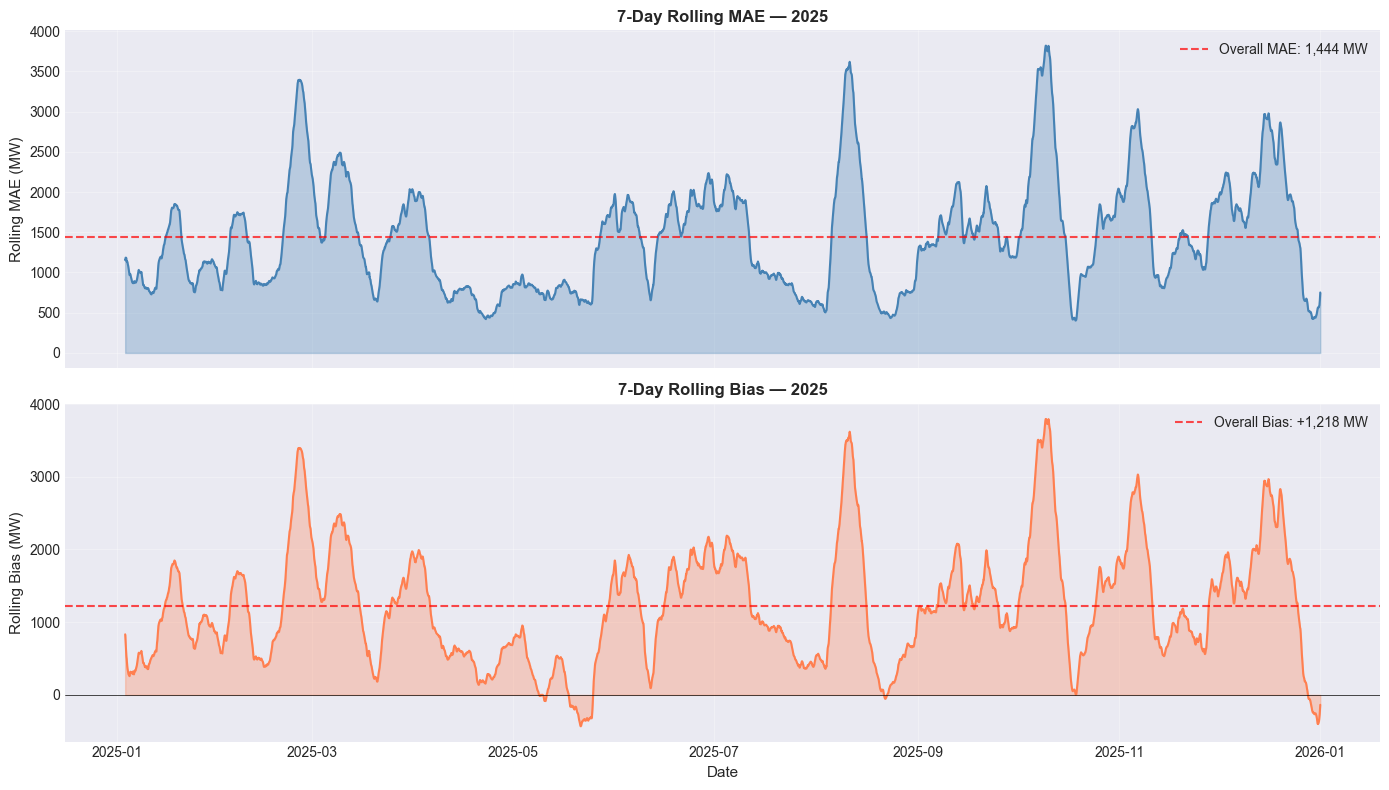


 Trend Analysis (First Half vs Second Half of 2025):
-------------------------------------------------------
   First Half (Jan-Jun):  MAE = 1,324 MW | Bias = +1,078 MW
   Second Half (Jul-Dec): MAE = 1,563 MW | Bias = +1,358 MW
   Change:                MAE +239 MW (+18.0%)

  High-error periods (rolling MAE > 2,165 MW):
   Found 1134 timesteps exceeding threshold


In [45]:
# Analysis 5: Rolling MAE over Time
# Sort by time and compute rolling metrics
matched_2025_sorted = matched_2025.sort_values('time').copy()

# Compute rolling MAE with 7-day window (168 hourly points, but we have ~1 point/hour so use 168)
# Since data is hourly, 7 days = 168 points approximately
window_size = 168  # 7 days
matched_2025_sorted['rolling_mae'] = matched_2025_sorted['abs_error'].rolling(window=window_size, min_periods=50).mean()
matched_2025_sorted['rolling_bias'] = matched_2025_sorted['error'].rolling(window=window_size, min_periods=50).mean()

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: Rolling MAE
ax1 = axes[0]
ax1.plot(matched_2025_sorted['time'], matched_2025_sorted['rolling_mae'], color='steelblue', linewidth=1.5)
ax1.axhline(y=matched_2025['abs_error'].mean(), color='red', linestyle='--', alpha=0.7, label=f'Overall MAE: {matched_2025["abs_error"].mean():,.0f} MW')
ax1.fill_between(matched_2025_sorted['time'], matched_2025_sorted['rolling_mae'], alpha=0.3, color='steelblue')
ax1.set_ylabel('Rolling MAE (MW)', fontsize=11)
ax1.set_title('7-Day Rolling MAE — 2025', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Bottom: Rolling Bias
ax2 = axes[1]
ax2.plot(matched_2025_sorted['time'], matched_2025_sorted['rolling_bias'], color='coral', linewidth=1.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.axhline(y=matched_2025['error'].mean(), color='red', linestyle='--', alpha=0.7, label=f'Overall Bias: {matched_2025["error"].mean():+,.0f} MW')
ax2.fill_between(matched_2025_sorted['time'], matched_2025_sorted['rolling_bias'], alpha=0.3, color='coral')
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Rolling Bias (MW)', fontsize=11)
ax2.set_title('7-Day Rolling Bias — 2025', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analysis6_rolling_mae.png', dpi=150, bbox_inches='tight')
plt.show()

# Trend analysis: compare first half vs second half
midpoint = len(matched_2025_sorted) // 2
first_half = matched_2025_sorted.iloc[:midpoint]
second_half = matched_2025_sorted.iloc[midpoint:]

print("\n Trend Analysis (First Half vs Second Half of 2025):")
print("-" * 55)
print(f"   First Half (Jan-Jun):  MAE = {first_half['abs_error'].mean():,.0f} MW | Bias = {first_half['error'].mean():+,.0f} MW")
print(f"   Second Half (Jul-Dec): MAE = {second_half['abs_error'].mean():,.0f} MW | Bias = {second_half['error'].mean():+,.0f} MW")
print(f"   Change:                MAE {second_half['abs_error'].mean() - first_half['abs_error'].mean():+,.0f} MW ({((second_half['abs_error'].mean()/first_half['abs_error'].mean())-1)*100:+.1f}%)")

# Identify worst periods (peaks in rolling MAE)
threshold = matched_2025['abs_error'].mean() * 1.5
high_error_periods = matched_2025_sorted[matched_2025_sorted['rolling_mae'] > threshold]['time']
if len(high_error_periods) > 0:
    print(f"\n  High-error periods (rolling MAE > {threshold:,.0f} MW):")
    # Group consecutive dates
    high_error_periods_dt = pd.to_datetime(high_error_periods)
    print(f"   Found {len(high_error_periods)} timesteps exceeding threshold")

Key Findings:

**No model improvement over time** — performance degraded rather than learned
**Weather events drive errors** — spikes suggest storm systems break the model
**Calm periods prove model capability** — Apr-May shows what's achievable
**Overestimation worsens under stress** — bias amplifies during high-error periods
**Seasonal retraining may help** — distinct error regimes suggest adaptive models needed

**Conclusion:** The model isn't self correcting. Accuracy depends entirely on weather stability, indicating a need for regime aware forecasting.

### Analysis 6 : Scatter Plot Actual vs Forecast
How well does the model track actual generation?

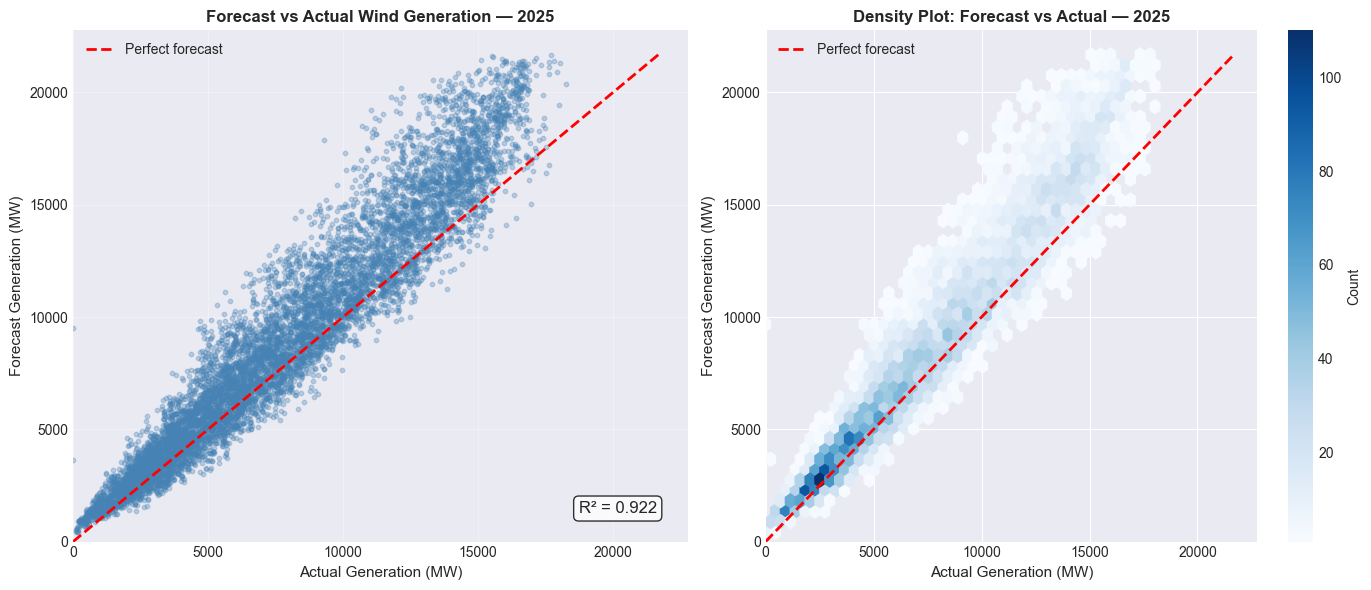


Correlation Analysis:
   Pearson correlation: 0.960
   R² (variance explained): 0.922 (92.2%)

Bias by Generation Level:
   Low wind  (<4,159 MW):  Bias = +539 MW
   Mid wind  (4,159-11,429 MW): Bias = +1,095 MW
   High wind (>11,429 MW): Bias = +2,144 MW


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Scatter plot with perfect prediction line
ax1 = axes[0]
ax1.scatter(matched_2025['actual'], matched_2025['forecast'], alpha=0.3, s=10, color='steelblue')
max_val = max(matched_2025['actual'].max(), matched_2025['forecast'].max())
ax1.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect forecast')
ax1.set_xlabel('Actual Generation (MW)', fontsize=11)
ax1.set_ylabel('Forecast Generation (MW)', fontsize=11)
ax1.set_title('Forecast vs Actual Wind Generation — 2025', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left')
ax1.set_xlim(0, max_val * 1.05)
ax1.set_ylim(0, max_val * 1.05)
ax1.grid(True, alpha=0.3)

# Add correlation coefficient
corr = matched_2025['actual'].corr(matched_2025['forecast'])
ax1.text(0.95, 0.05, f'R² = {corr**2:.3f}', transform=ax1.transAxes, fontsize=12,
         ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Right: Hexbin for density visualization
ax2 = axes[1]
hb = ax2.hexbin(matched_2025['actual'], matched_2025['forecast'], gridsize=40, cmap='Blues', mincnt=1)
ax2.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect forecast')
ax2.set_xlabel('Actual Generation (MW)', fontsize=11)
ax2.set_ylabel('Forecast Generation (MW)', fontsize=11)
ax2.set_title('Density Plot: Forecast vs Actual — 2025', fontsize=12, fontweight='bold')
ax2.set_xlim(0, max_val * 1.05)
ax2.set_ylim(0, max_val * 1.05)
ax2.legend(loc='upper left')
plt.colorbar(hb, ax=ax2, label='Count')

plt.tight_layout()
plt.savefig('analysis7_scatter_actual_vs_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\nCorrelation Analysis:")
print(f"   Pearson correlation: {corr:.3f}")
print(f"   R² (variance explained): {corr**2:.3f} ({corr**2*100:.1f}%)")

# Analyze bias at different generation levels
quartiles = matched_2025['actual'].quantile([0.25, 0.5, 0.75])
low = matched_2025[matched_2025['actual'] <= quartiles[0.25]]
mid = matched_2025[(matched_2025['actual'] > quartiles[0.25]) & (matched_2025['actual'] <= quartiles[0.75])]
high = matched_2025[matched_2025['actual'] > quartiles[0.75]]

print(f"\nBias by Generation Level:")
print(f"   Low wind  (<{quartiles[0.25]:,.0f} MW):  Bias = {low['error'].mean():+,.0f} MW")
print(f"   Mid wind  ({quartiles[0.25]:,.0f}-{quartiles[0.75]:,.0f} MW): Bias = {mid['error'].mean():+,.0f} MW")
print(f"   High wind (>{quartiles[0.75]:,.0f} MW): Bias = {high['error'].mean():+,.0f} MW")

**Key Findings:**

- **Strong correlation (R²=92%)** — model captures overall wind patterns well
- **Systematic overestimation visible** — points cluster above the perfect line
- **Bias scales with generation** — higher wind means larger overestimation (+2,144 MW at high wind)
- **Low wind forecasts most accurate** — bias only +539 MW when actual <4 GW
- **Density concentrated mid-range** — most forecasts occur in 5-12 GW band

**Conclusion:** 
The model tracks wind well directionally but increasingly overestimates as generation rises — a scaling calibration issue, not a fundamental model flaw.

### Analysis 7: Error vs Actual Generation Level
Does the model perform worse during low or high wind?

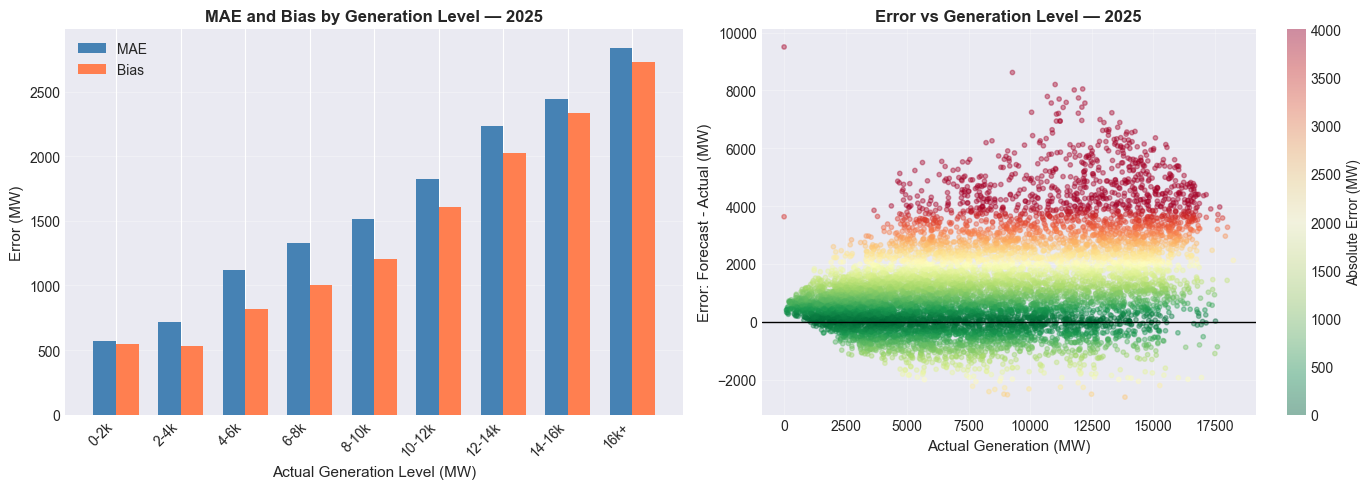


Error Metrics by Generation Level:
gen_bin    MAE   Bias  Count
   0-2k  568.0  549.0    583
   2-4k  718.0  531.0   1489
   4-6k 1116.0  820.0   1429
   6-8k 1325.0 1006.0   1298
  8-10k 1511.0 1206.0   1133
 10-12k 1822.0 1607.0    927
 12-14k 2231.0 2021.0    916
 14-16k 2446.0 2332.0    784
   16k+ 2839.0 2727.0    192

Relative Error (MAE as % of generation):
   0-2k    :  44.7%
   2-4k    :  23.6%
   4-6k    :  22.2%
   6-8k    :  19.0%
   8-10k   :  16.9%
   10-12k  :  16.6%
   12-14k  :  17.2%
   14-16k  :  16.4%
   16k+    :  17.1%


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create generation bins
bins = [0, 2000, 4000, 6000, 8000, 10000, 12000, 14000, 16000, 20000]
labels = ['0-2k', '2-4k', '4-6k', '6-8k', '8-10k', '10-12k', '12-14k', '14-16k', '16k+']
matched_2025['gen_bin'] = pd.cut(matched_2025['actual'], bins=bins, labels=labels)

# Compute metrics by generation bin
bin_metrics = matched_2025.groupby('gen_bin', observed=True).agg(
    MAE=('abs_error', 'mean'),
    Bias=('error', 'mean'),
    Count=('error', 'count'),
    MeanActual=('actual', 'mean')
).reset_index()

# Left: MAE and Bias by generation level
ax1 = axes[0]
x = range(len(bin_metrics))
width = 0.35
ax1.bar([i - width/2 for i in x], bin_metrics['MAE'], width, label='MAE', color='steelblue')
ax1.bar([i + width/2 for i in x], bin_metrics['Bias'], width, label='Bias', color='coral')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Actual Generation Level (MW)', fontsize=11)
ax1.set_ylabel('Error (MW)', fontsize=11)
ax1.set_title('MAE and Bias by Generation Level — 2025', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(bin_metrics['gen_bin'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Right: Scatter with error colored by magnitude
ax2 = axes[1]
scatter = ax2.scatter(matched_2025['actual'], matched_2025['error'], 
                       c=matched_2025['abs_error'], cmap='RdYlGn_r', 
                       alpha=0.4, s=10, vmin=0, vmax=4000)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Actual Generation (MW)', fontsize=11)
ax2.set_ylabel('Error: Forecast - Actual (MW)', fontsize=11)
ax2.set_title('Error vs Generation Level — 2025', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax2, label='Absolute Error (MW)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analysis8_error_vs_generation.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\nError Metrics by Generation Level:")
print(bin_metrics[['gen_bin', 'MAE', 'Bias', 'Count']].round(0).to_string(index=False))

# Relative error analysis
print(f"\nRelative Error (MAE as % of generation):")
for _, row in bin_metrics.iterrows():
    pct = (row['MAE'] / row['MeanActual']) * 100
    print(f"   {row['gen_bin']:8s}: {pct:5.1f}%")

**Key Findings:**

- **Absolute error grows with generation** — MAE rises from 568 MW (low wind) to 2,839 MW (high wind)
- **Bias is almost entirely positive** — model overestimates at every generation level
- **Relative error tells opposite story** — 45% error at low wind vs 17% at high wind
- **Sweet spot is 8-12 GW range** — best balance of absolute and relative accuracy (~17%)
- **High wind errors are asymmetric** — scatter shows large positive errors dominate above 12 GW

**Conclusion:** The model struggles differently at extremes: low wind has high relative uncertainty, high wind has large absolute overestimation. Mid-range generation is most reliably forecast.

### Analysis 8: Autocorrelation of Errors
Are errors random or do they cluster in time?

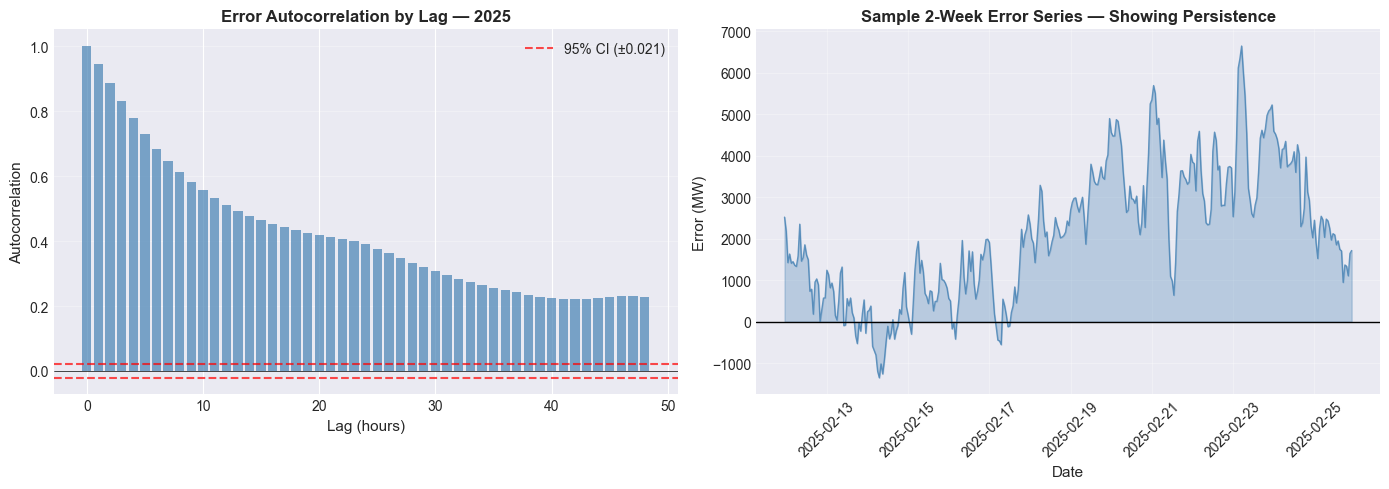


Autocorrelation Analysis:
   Lag-1 autocorrelation:  0.945
   Lag-6 autocorrelation:  0.684
   Lag-12 autocorrelation: 0.512
   Lag-24 autocorrelation: 0.390
   Significance threshold: ±0.021

Error Streak Analysis:
   Average streak length: 10.9 hours
   Median streak length:  3 hours
   Max streak length:     231 hours
   Streaks > 12 hours:    159 occurrences


In [51]:
from scipy import stats

# Sort by time
errors_sorted = matched_2025.sort_values('time')['error'].values

# Compute autocorrelation for different lags
max_lag = 48  # 48 hours
autocorr = [pd.Series(errors_sorted).autocorr(lag=i) for i in range(max_lag + 1)]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Autocorrelation plot
ax1 = axes[0]
ax1.bar(range(max_lag + 1), autocorr, color='steelblue', alpha=0.7)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
# Add significance threshold (95% CI for white noise)
n = len(errors_sorted)
sig_threshold = 1.96 / np.sqrt(n)
ax1.axhline(y=sig_threshold, color='red', linestyle='--', alpha=0.7, label=f'95% CI (±{sig_threshold:.3f})')
ax1.axhline(y=-sig_threshold, color='red', linestyle='--', alpha=0.7)
ax1.set_xlabel('Lag (hours)', fontsize=11)
ax1.set_ylabel('Autocorrelation', fontsize=11)
ax1.set_title('Error Autocorrelation by Lag — 2025', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Right: Error time series showing persistence
ax2 = axes[1]
# Take a 2-week sample to show clustering
sample_start = 1000
sample_end = sample_start + 336  # 2 weeks
sample = matched_2025.sort_values('time').iloc[sample_start:sample_end]
ax2.plot(sample['time'], sample['error'], color='steelblue', linewidth=1, alpha=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.fill_between(sample['time'], sample['error'], 0, alpha=0.3, color='steelblue')
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Error (MW)', fontsize=11)
ax2.set_title('Sample 2-Week Error Series — Showing Persistence', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analysis9_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\nAutocorrelation Analysis:")
print(f"   Lag-1 autocorrelation:  {autocorr[1]:.3f}")
print(f"   Lag-6 autocorrelation:  {autocorr[6]:.3f}")
print(f"   Lag-12 autocorrelation: {autocorr[12]:.3f}")
print(f"   Lag-24 autocorrelation: {autocorr[24]:.3f}")
print(f"   Significance threshold: ±{sig_threshold:.3f}")

# Run length analysis - how long do error streaks last?
error_signs = np.sign(errors_sorted)
runs = []
current_run = 1
for i in range(1, len(error_signs)):
    if error_signs[i] == error_signs[i-1]:
        current_run += 1
    else:
        runs.append(current_run)
        current_run = 1
runs.append(current_run)

print(f"\nError Streak Analysis:")
print(f"   Average streak length: {np.mean(runs):.1f} hours")
print(f"   Median streak length:  {np.median(runs):.0f} hours")
print(f"   Max streak length:     {np.max(runs)} hours")
print(f"   Streaks > 12 hours:    {sum(1 for r in runs if r > 12)} occurrences")

**Key Findings:**

- **Errors are highly persistent** — Lag-1 autocorrelation of 0.945 means errors barely change hour-to-hour
- **Correlation persists for days** — still 0.39 at 24-hour lag, well above significance threshold
- **Error streaks last ~11 hours on average** — median is 3 hours, but max streak was 231 hours (~10 days)
- **159 streaks exceeded 12 hours** — prolonged error regimes are common, not exceptional
- **Sample shows multi-day persistence** — Feb 19-25 shows sustained overestimation for nearly a week

**Conclusion:** Errors are not random noise — they cluster into prolonged regimes driven by weather patterns. Once the model starts over/underestimating, it continues for hours or days.

**Possible Solutions:**
- *High lag-1 correlation* → Use recent error to adjust next forecast (autoregressive correction)
- *Multi-day persistence* → Implement regime detection to identify when model enters error state
- *Long error streaks* → Trigger manual review or alternative model when streak exceeds threshold
- *Weather-driven clustering* → Incorporate weather regime classification into forecast pipeline

### Analysis 9: Skill Score vs Persistence Baseline
Is the model better than assuming wind stays constant?

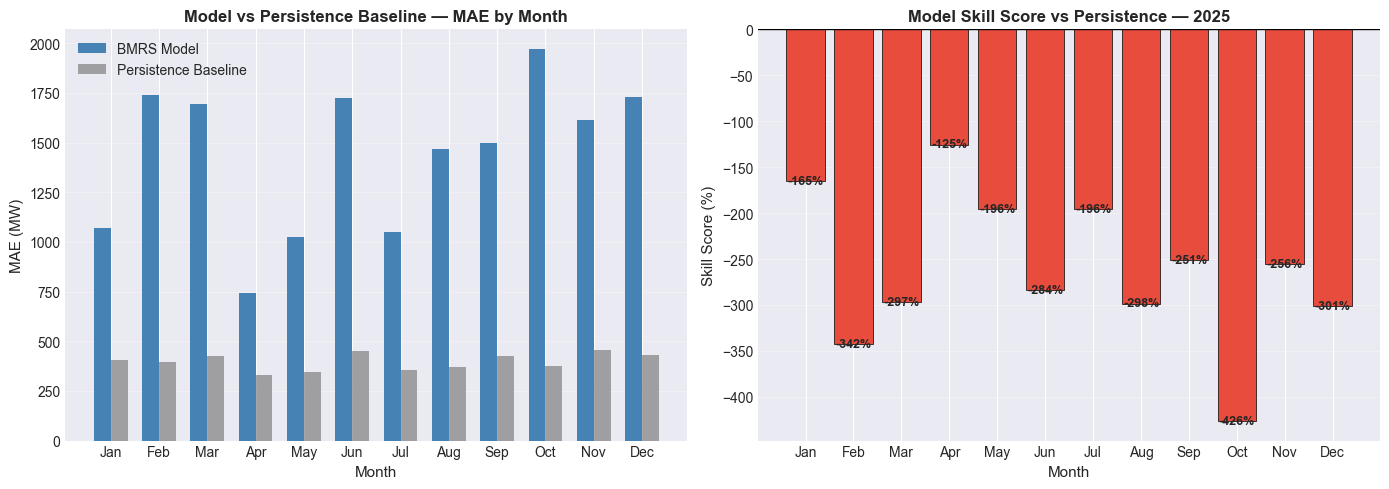


Overall Skill Score (Model vs Persistence):
   Model MAE:        1,442 MW
   Persistence MAE:  396 MW
   MAE Skill Score:  -263.9%

   Model RMSE:       1,977 MW
   Persistence RMSE: 543 MW
   RMSE Skill Score: -263.9%

Model beats persistence 19.5% of the time


In [53]:
# Persistence forecast = assume next value equals current value

# Sort by time and create persistence forecast (previous actual as forecast)
df_skill = matched_2025.sort_values('time').copy()
df_skill['persistence_forecast'] = df_skill['actual'].shift(1)
df_skill = df_skill.dropna()  # Remove first row with NaN

# Compute errors for both models
df_skill['model_error'] = df_skill['forecast'] - df_skill['actual']
df_skill['persistence_error'] = df_skill['persistence_forecast'] - df_skill['actual']
df_skill['model_abs_error'] = df_skill['model_error'].abs()
df_skill['persistence_abs_error'] = df_skill['persistence_error'].abs()

# Compute skill scores
model_mae = df_skill['model_abs_error'].mean()
persistence_mae = df_skill['persistence_abs_error'].mean()
model_rmse = np.sqrt((df_skill['model_error'] ** 2).mean())
persistence_rmse = np.sqrt((df_skill['persistence_error'] ** 2).mean())

# Skill score: (1 - model_error/baseline_error) * 100
mae_skill = (1 - model_mae / persistence_mae) * 100
rmse_skill = (1 - model_rmse / persistence_rmse) * 100

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Compare MAE by month
df_skill['month_name'] = df_skill['time'].dt.strftime('%b')
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_comparison = df_skill.groupby('month_name').agg(
    Model_MAE=('model_abs_error', 'mean'),
    Persistence_MAE=('persistence_abs_error', 'mean')
).reindex(month_order)
monthly_comparison['Skill_Score'] = (1 - monthly_comparison['Model_MAE'] / monthly_comparison['Persistence_MAE']) * 100

ax1 = axes[0]
x = range(len(month_order))
width = 0.35
ax1.bar([i - width/2 for i in x], monthly_comparison['Model_MAE'], width, label='BMRS Model', color='steelblue')
ax1.bar([i + width/2 for i in x], monthly_comparison['Persistence_MAE'], width, label='Persistence Baseline', color='gray', alpha=0.7)
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('MAE (MW)', fontsize=11)
ax1.set_title('Model vs Persistence Baseline — MAE by Month', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(month_order)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Right: Skill score by month
ax2 = axes[1]
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in monthly_comparison['Skill_Score']]
ax2.bar(month_order, monthly_comparison['Skill_Score'], color=colors, edgecolor='black', linewidth=0.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Skill Score (%)', fontsize=11)
ax2.set_title('Model Skill Score vs Persistence — 2025', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add annotation
for i, v in enumerate(monthly_comparison['Skill_Score']):
    ax2.text(i, v + 1 if v >= 0 else v - 3, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('analysis10_skill_score.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\nOverall Skill Score (Model vs Persistence):")
print(f"   Model MAE:        {model_mae:,.0f} MW")
print(f"   Persistence MAE:  {persistence_mae:,.0f} MW")
print(f"   MAE Skill Score:  {mae_skill:+.1f}%")
print(f"\n   Model RMSE:       {model_rmse:,.0f} MW")
print(f"   Persistence RMSE: {persistence_rmse:,.0f} MW")
print(f"   RMSE Skill Score: {rmse_skill:+.1f}%")

# When does model beat persistence?
df_skill['model_wins'] = df_skill['model_abs_error'] < df_skill['persistence_abs_error']
win_rate = df_skill['model_wins'].mean() * 100
print(f"\nModel beats persistence {win_rate:.1f}% of the time")

**Key Findings:**

- **Model is worse than persistence** — skill score of -264% means model adds error, not value
- **Persistence baseline MAE is only 396 MW** — simply using last actual beats the 4h forecast
- **Model loses every single month** — all months show negative skill, ranging from -125% to -426%
- **October is worst** — skill score of -426%, model is 4x worse than just assuming no change
- **Model only wins 19.5% of timesteps** — persistence beats the forecast 80% of the time

**Conclusion:** 
At 4-hour horizon, the BMRS wind forecast adds no value over naive persistence. The model's systematic bias destroys any predictive skill it might have.

**Possible Solutions:**
- *Negative skill score* → Blend model with persistence: use weighted average of both forecasts
- *Systematic bias destroying value* → Apply bias correction before deployment; raw model is harmful
- *Model rarely wins* → Use persistence as default, switch to model only when conditions favor it
- *Fundamental model issue* → Investigate if 4h horizon is beyond model's reliable range; test shorter horizons

### **Final Insights and Recommendations**


### **How good is the model?**

The model demonstrates reasonable baseline stability, with most predictions staying within a predictable range of error. On average, it captures the general trend of the data, which indicates that it has learned the underlying patterns to some extent. However, the presence of a consistent positive bias (~+1,290 MW) suggests that the model systematically overestimates generation rather than making purely random mistakes. This reduces its reliability in real-world scenarios, as the errors are not centered around zero. Additionally, while median errors may appear acceptable, the p99 error reveals occasional but significant deviations, indicating that the model is not robust under extreme or volatile conditions. Overall, the model is usable for broad directional insights but not yet dependable for precise operational decision-making.

---

### **Where exactly does it fail and why is it failing?**

The model's weaknesses are structured rather than random, which makes them both identifiable and correctable.

- **Systematic Bias:** The consistent overestimation indicates a calibration issue. This could stem from imbalanced training data, improper loss optimization, or missing corrective mechanisms that align predictions with actual distributions.

- **Forecast Horizon Degradation:** Errors increase as the forecast horizon extends. This suggests that the model struggles with error propagation, where small initial inaccuracies compound over time. It also indicates limited ability to capture long-term dependencies or evolving external factors.

- **Time-of-Day Variability:** The model performs unevenly across different times of the day, likely due to unmodeled cyclical patterns or insufficient representation of temporal features (e.g., demand cycles, environmental changes).

- **Extreme Errors (Tail Risk):** The high p99 error highlights that the model is particularly unreliable during edge cases or high-variance scenarios. This suggests that rare events are either underrepresented in training data or not properly learned by the model.

In essence, the model is failing not because it lacks learning capability, but because it lacks calibration, temporal awareness, and robustness to variability.

---

### **What should be done next?**

Improving this model requires targeted interventions rather than a complete redesign:

- **Bias Correction / Calibration:** Introduce a post-processing calibration layer or adjust the loss function to penalize systematic overestimation, bringing predictions closer to actual values.

- **Horizon-Specific Modeling:** Consider training separate models (or using multi-head architectures) for different forecast horizons to reduce compounded error effects.

- **Enhanced Temporal Features:** Incorporate richer time-based signals (hour-of-day, seasonality, lag features) to better capture cyclical behavior.

- **Handling Extreme Cases:** Improve robustness by including more diverse training samples or using techniques like quantile regression or probabilistic forecasting, which better account for uncertainty and tail risks.

- **Model Monitoring & Retraining:** Establish continuous evaluation pipelines to track drift and periodically recalibrate the model as new data becomes available.

---

**Final takeaway:**  
The model has a solid foundational understanding of the data but is currently miscalibrated and inconsistent under stress. With focused improvements in calibration, temporal modeling, and robustness, it has strong potential to evolve into a reliable forecasting system.